# PART 8

Haikal Ali_1103223071_TK46GAB

# Chapter 8 - Matrix Inverse



## 1. Matrix Inverse

Inverse dari matriks $A$ adalah matriks lain yang ditulis sebagai $A^{-1}$. Inverse digunakan untuk mengubah matriks menjadi identity matrix melalui perkalian matriks:

$$A^{-1}A = I$$

Inverse berguna untuk menyelesaikan persamaan matriks berbentuk:

$$Ax = b$$

Dengan mengalikan kedua sisi oleh $A^{-1}$, solusi dapat ditulis sebagai:

$$x = A^{-1}b$$

## 2. Jenis Inverse dan Syarat Invertibility

Ada tiga jenis inverse:

1. **Full inverse**: berlaku jika matriks berbentuk square dan full-rank.
2. **One-sided inverse**: berlaku untuk matriks rectangular tertentu. Tall matrix dapat memiliki left-inverse, sedangkan wide matrix dapat memiliki right-inverse.
3. **Pseudoinverse**: dapat dihitung untuk semua matriks, termasuk matriks reduced-rank.

Matriks yang tidak memiliki full inverse atau one-sided inverse disebut **singular** atau **noninvertible**.

## 3. Setup Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hilbert

np.set_printoptions(precision=4, suppress=True)

## 4. Computing the Inverse

Untuk skalar, inverse cukup berupa reciprocal. Namun untuk matriks, inverse **tidak** diperoleh dengan membalik setiap elemen satu per satu. Matriks inverse harus memenuhi syarat bahwa hasil perkaliannya dengan matriks asal menghasilkan identity matrix.

### Inverse Matriks 2 x 2

Untuk matriks:

$$A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$$

inverse-nya adalah:

$$A^{-1} = \frac{1}{ad-bc}\begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$

Syaratnya, determinant tidak boleh nol.

In [2]:
A = np.array([[1,4],[2,7]])
Ainv = np.linalg.inv(A)

print('A:')
print(A)
print('\nA inverse:')
print(Ainv)
print('\nA @ Ainv:')
print(A @ Ainv)
print('\nAinv @ A:')
print(Ainv @ A)

A:
[[1 4]
 [2 7]]

A inverse:
[[-7.  4.]
 [ 2. -1.]]

A @ Ainv:
[[1. 0.]
 [0. 1.]]

Ainv @ A:
[[1. 0.]
 [0. 1.]]


### Visualisasi Matriks, Inverse, dan Produk

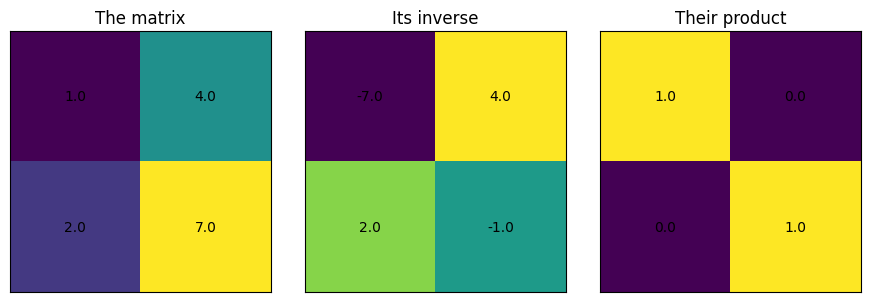

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
matrices = [A, Ainv, A @ Ainv]
titles = ['The matrix', 'Its inverse', 'Their product']

for ax, mat, title in zip(axs, matrices, titles):
  ax.imshow(mat)
  ax.set_title(title)
  for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
      ax.text(j, i, f'{mat[i,j]:.1f}', ha='center', va='center')
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()

### Matriks Singular Tidak Memiliki Full Inverse

Contoh berikut menghasilkan error karena determinant matriks bernilai nol, sehingga matriks bersifat singular.

In [4]:
A = np.array([[1,4],[2,8]])

try:
  Ainv = np.linalg.inv(A)
  print(A @ Ainv)
except np.linalg.LinAlgError as err:
  print('Error:', err)

Error: Singular matrix


### Inverse Matriks Diagonal

Untuk square diagonal matrix, inverse diperoleh dengan membalik elemen-elemen diagonalnya. Jika ada diagonal yang bernilai nol, maka matriks tidak memiliki inverse.

In [5]:
D = np.diag([2, 3, 4])
Dinv = np.linalg.inv(D)

print('D:')
print(D)
print('\nD inverse:')
print(Dinv)
print('\nD @ Dinv:')
print(D @ Dinv)

D:
[[2 0 0]
 [0 3 0]
 [0 0 4]]

D inverse:
[[0.5    0.     0.    ]
 [0.     0.3333 0.    ]
 [0.     0.     0.25  ]]

D @ Dinv:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


## 5. Inverting Any Square Full-Rank Matrix

Algoritma full inverse untuk square full-rank matrix menggunakan beberapa matriks antara:

1. **Minors matrix**: berisi determinant dari submatrix yang dibuat dengan menghapus baris dan kolom tertentu.
2. **Grid matrix**: checkerboard berisi $+1$ dan $-1$.
3. **Cofactors matrix**: hasil Hadamard multiplication antara minors matrix dan grid matrix.
4. **Adjugate matrix**: transpose dari cofactors matrix, lalu dibagi determinant matriks asal.

In [6]:
def inverse_by_adjugate(A):
  A = np.array(A, dtype=float)
  n, m = A.shape

  if n != m:
    raise ValueError('Matriks harus square.')

  detA = np.linalg.det(A)
  if np.isclose(detA, 0):
    raise np.linalg.LinAlgError('Singular matrix')

  minors = np.zeros((n, n))
  grid = np.zeros((n, n))

  for i in range(n):
    for j in range(n):
      submatrix = np.delete(np.delete(A, i, axis=0), j, axis=1)
      minors[i, j] = np.linalg.det(submatrix)
      grid[i, j] = (-1) ** (i + j)

  cofactors = minors * grid
  adjugate = cofactors.T / detA

  return adjugate, minors, grid, cofactors

A = np.random.randn(4, 4)
Ainv_manual, minors, grid, cofactors = inverse_by_adjugate(A)
Ainv_numpy = np.linalg.inv(A)

print('Jarak manual inverse dengan np.linalg.inv:')
print(np.linalg.norm(Ainv_manual - Ainv_numpy))
print('\nA @ inverse manual:')
print(A @ Ainv_manual)

Jarak manual inverse dengan np.linalg.inv:
5.078801087502965e-16

A @ inverse manual:
[[ 1.  0. -0. -0.]
 [-0.  1. -0. -0.]
 [-0.  0.  1.  0.]
 [-0.  0.  0.  1.]]


## 6. One-Sided Inverses

Tall matrix tidak memiliki full inverse, tetapi dapat memiliki **left-inverse** jika full column-rank.

Untuk tall matrix $T$, left-inverse dihitung sebagai:

$$L = (T^T T)^{-1}T^T$$

Maka:

$$LT = I$$

Namun umumnya:

$$TL \neq I$$

In [7]:
T = np.random.randint(-10, 11, size=(40, 4))
TtT = T.T @ T
TtT_inv = np.linalg.inv(TtT)

L = TtT_inv @ T.T

print('Shape T:', T.shape)
print('Shape L:', L.shape)
print('\nL @ T:')
print(L @ T)
print('\nT @ L shape:', (T @ L).shape)

Shape T: (40, 4)
Shape L: (4, 40)

L @ T:
[[ 1. -0.  0.  0.]
 [-0.  1. -0.  0.]
 [ 0. -0.  1.  0.]
 [-0.  0.  0.  1.]]

T @ L shape: (40, 40)


## 7. The Inverse Is Unique

Matrix inverse bersifat unik. Jika sebuah matriks memiliki inverse, maka inverse tersebut hanya satu. Tidak mungkin ada dua matriks berbeda yang sama-sama menjadi inverse dari matriks yang sama.

## 8. Moore-Penrose Pseudoinverse

Reduced-rank matrix tidak memiliki full inverse, tetapi tetap memiliki pseudoinverse. Pseudoinverse yang paling umum digunakan adalah **Moore-Penrose pseudoinverse**, dihitung di NumPy dengan `np.linalg.pinv()`.

In [8]:
A = np.array([[1,4],[2,8]])
Apinv = np.linalg.pinv(A)

print('A pseudoinverse:')
print(Apinv)
print('\nA @ Apinv:')
print(A @ Apinv)

A pseudoinverse:
[[0.0118 0.0235]
 [0.0471 0.0941]]

A @ Apinv:
[[0.2 0.4]
 [0.4 0.8]]


## 9. Numerical Stability of the Inverse

Menghitung inverse dapat memiliki masalah numerical stability. Salah satu contoh matriks yang bermasalah adalah **Hilbert matrix**, yang elemennya didefinisikan sebagai:

$$h_{i,j} = \frac{1}{i+j-1}$$

Semakin besar ukurannya, Hilbert matrix cenderung makin tidak stabil secara numerik.

In [9]:
def hilbert_matrix(n):
  H = np.zeros((n, n))
  for i in range(n):
    for j in range(n):
      H[i, j] = 1 / (i + j + 1)
  return H

H = hilbert_matrix(5)
Hinv = np.linalg.inv(H)
product = H @ Hinv

print('Hilbert matrix:')
print(H)
print('\nInverse Hilbert:')
print(Hinv)
print('\nProduct:')
print(product)

Hilbert matrix:
[[1.     0.5    0.3333 0.25   0.2   ]
 [0.5    0.3333 0.25   0.2    0.1667]
 [0.3333 0.25   0.2    0.1667 0.1429]
 [0.25   0.2    0.1667 0.1429 0.125 ]
 [0.2    0.1667 0.1429 0.125  0.1111]]

Inverse Hilbert:
[[     25.    -300.    1050.   -1400.     630.]
 [   -300.    4800.  -18900.   26880.  -12600.]
 [   1050.  -18900.   79380. -117600.   56700.]
 [  -1400.   26880. -117600.  179200.  -88200.]
 [    630.  -12600.   56700.  -88200.   44100.]]

Product:
[[ 1.  0. -0.  0. -0.]
 [-0.  1. -0.  0.  0.]
 [ 0. -0.  1.  0.  0.]
 [-0.  0. -0.  1. -0.]
 [ 0. -0.  0. -0.  1.]]


## 10. Geometric Interpretation of the Inverse

Matrix-vector multiplication dapat dipahami sebagai geometric transformation. Matrix inverse dapat dipahami sebagai operasi yang membatalkan transformasi tersebut.

Jika:

$$Q = TP$$

maka:

$$T^{-1}Q = P$$

# Code Exercises

## Exercise 8-1

Inverse dari inverse adalah matriks asal:

$$(A^{-1})^{-1} = A$$

In [10]:
A = np.random.randn(4, 4)
A_inv_inv = np.linalg.inv(np.linalg.inv(A))

print('Jarak antara A dan inverse dari inverse A:')
print(np.linalg.norm(A - A_inv_inv))
print('\nnp.allclose(A, A_inv_inv):', np.allclose(A, A_inv_inv))

Jarak antara A dan inverse dari inverse A:
6.881431786639679e-16

np.allclose(A, A_inv_inv): True


## Exercise 8-2

Implementasi algoritma full inverse menggunakan minors, grid, cofactors, dan adjugate matrix.

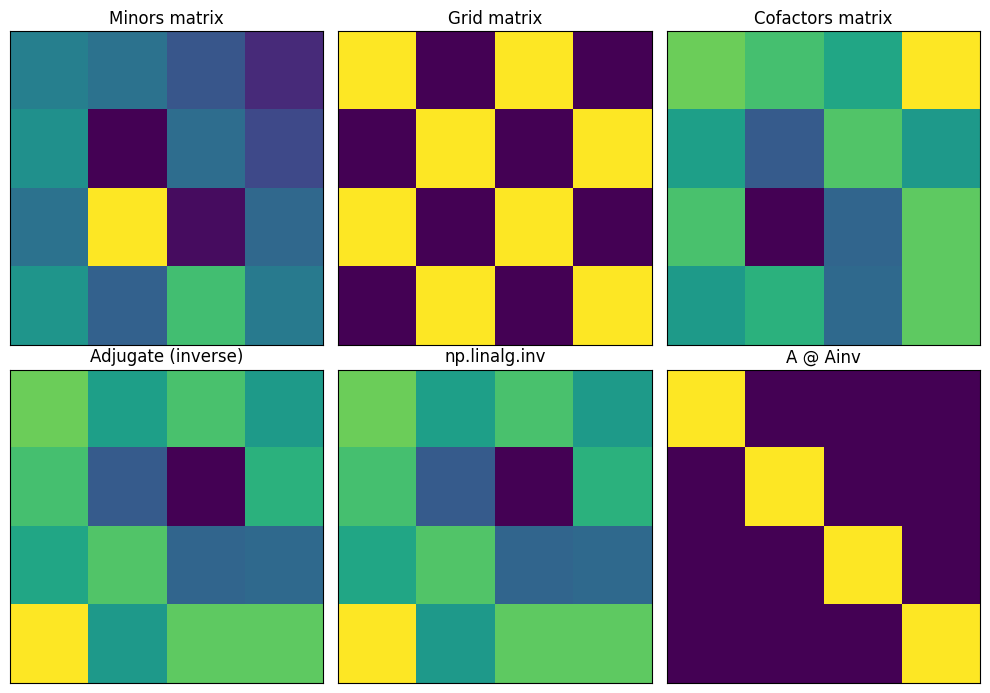

Jarak adjugate inverse dengan np.linalg.inv:
1.5908880303874402e-15


In [11]:
A = np.random.randn(4, 4)
Ainv_adj, minors, grid, cofactors = inverse_by_adjugate(A)
Ainv_np = np.linalg.inv(A)
identity_test = A @ Ainv_adj

fig, axs = plt.subplots(2, 3, figsize=(10, 7))
plots = [minors, grid, cofactors, Ainv_adj, Ainv_np, identity_test]
titles = ['Minors matrix', 'Grid matrix', 'Cofactors matrix', 'Adjugate (inverse)', 'np.linalg.inv', 'A @ Ainv']

for ax, mat, title in zip(axs.ravel(), plots, titles):
  ax.imshow(mat)
  ax.set_title(title)
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()

print('Jarak adjugate inverse dengan np.linalg.inv:')
print(np.linalg.norm(Ainv_adj - Ainv_np))

## Exercise 8-3

Untuk matriks 2 x 2:

$$A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$$

Minors matrix:

$$\begin{bmatrix} d & c \\ b & a \end{bmatrix}$$

Grid matrix:

$$\begin{bmatrix} 1 & -1 \\ -1 & 1 \end{bmatrix}$$

Cofactors matrix:

$$\begin{bmatrix} d & -c \\ -b & a \end{bmatrix}$$

Adjugate matrix adalah transpose dari cofactors matrix, sehingga:

$$\text{adj}(A)=\begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$

Maka:

$$A^{-1}=\frac{1}{ad-bc}\begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$

In [12]:
a, b, c, d = 1, 4, 2, 7
A = np.array([[a, b], [c, d]])
Ainv_formula = (1 / (a*d - b*c)) * np.array([[d, -b], [-c, a]])

print('Inverse dari formula 2x2:')
print(Ainv_formula)
print('\nInverse dari NumPy:')
print(np.linalg.inv(A))
print('\nA @ Ainv_formula:')
print(A @ Ainv_formula)

Inverse dari formula 2x2:
[[-7.  4.]
 [ 2. -1.]]

Inverse dari NumPy:
[[-7.  4.]
 [ 2. -1.]]

A @ Ainv_formula:
[[1. 0.]
 [0. 1.]]


## Exercise 8-4

Right-inverse untuk wide matrix $W$ dapat diturunkan dengan logika yang mirip dengan left-inverse.

Untuk wide matrix:

$$R = W^T(WW^T)^{-1}$$

Maka:

$$WR = I$$

Namun umumnya:

$$RW \neq I$$

Shape W: (4, 40)
Shape R: (40, 4)

W @ R:
[[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [-0.  0.  1. -0.]
 [ 0.  0.  0.  1.]]

R @ W shape: (40, 40)


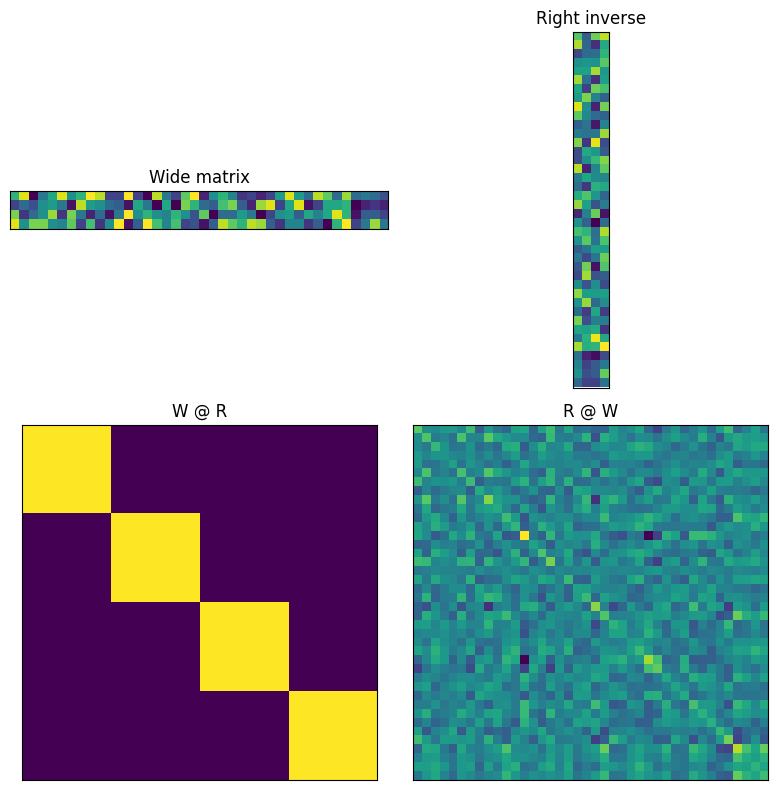

In [13]:
W = np.random.randint(-10, 11, size=(4, 40))
R = W.T @ np.linalg.inv(W @ W.T)

print('Shape W:', W.shape)
print('Shape R:', R.shape)
print('\nW @ R:')
print(W @ R)
print('\nR @ W shape:', (R @ W).shape)

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
plots = [W, R, W @ R, R @ W]
titles = ['Wide matrix', 'Right inverse', 'W @ R', 'R @ W']

for ax, mat, title in zip(axs.ravel(), plots, titles):
  ax.imshow(mat)
  ax.set_title(title)
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()

## Exercise 8-5

Pseudoinverse sama dengan full inverse untuk matriks invertible, sama dengan left-inverse untuk tall full column-rank matrix, dan sama dengan right-inverse untuk wide full row-rank matrix.

In [14]:
# Square full-rank matrix
A = np.random.randn(5, 5)
A_inv = np.linalg.inv(A)
A_pinv = np.linalg.pinv(A)
print('Square matrix: ||inv - pinv|| =', np.linalg.norm(A_inv - A_pinv))

# Tall full column-rank matrix
T = np.random.randn(10, 4)
L = np.linalg.inv(T.T @ T) @ T.T
T_pinv = np.linalg.pinv(T)
print('Tall matrix: ||left inverse - pinv|| =', np.linalg.norm(L - T_pinv))

# Wide full row-rank matrix
W = np.random.randn(4, 10)
R = W.T @ np.linalg.inv(W @ W.T)
W_pinv = np.linalg.pinv(W)
print('Wide matrix: ||right inverse - pinv|| =', np.linalg.norm(R - W_pinv))

Square matrix: ||inv - pinv|| = 1.5614381589165582e-14
Tall matrix: ||left inverse - pinv|| = 6.3292108719281425e-16
Wide matrix: ||right inverse - pinv|| = 4.3792513500982993e-16


## Exercise 8-6

LIVE EVIL rule berlaku untuk inverse dari perkalian matriks:

$$(AB)^{-1} = B^{-1}A^{-1}$$

Bukan:

$$(AB)^{-1} = A^{-1}B^{-1}$$

In [15]:
A = np.random.randn(4, 4)
B = np.random.randn(4, 4)

AB_inv = np.linalg.inv(A @ B)
Ainv_Binv = np.linalg.inv(A) @ np.linalg.inv(B)
Binv_Ainv = np.linalg.inv(B) @ np.linalg.inv(A)

print(f'Distance between (AB)^-1 and (A^-1)(B^-1) is {np.linalg.norm(AB_inv - Ainv_Binv):.10f}')
print(f'Distance between (AB)^-1 and (B^-1)(A^-1) is {np.linalg.norm(AB_inv - Binv_Ainv):.10f}')

# Extra: empat matriks
C = np.random.randn(4, 4)
D = np.random.randn(4, 4)
ABCD_inv = np.linalg.inv(A @ B @ C @ D)
DECB_inv = np.linalg.inv(D) @ np.linalg.inv(C) @ np.linalg.inv(B) @ np.linalg.inv(A)
print(f'Distance for four matrices is {np.linalg.norm(ABCD_inv - DECB_inv):.10f}')

Distance between (AB)^-1 and (A^-1)(B^-1) is 1.7151732726
Distance between (AB)^-1 and (B^-1)(A^-1) is 0.0000000000
Distance for four matrices is 0.0000000000


## Exercise 8-7

Pengujian LIVE EVIL rule pada one-sided inverse menggunakan pseudoinverse.

In [16]:
T = np.random.randn(10, 4)

left_side = np.linalg.inv(T.T @ T)
right_side = np.linalg.pinv(T) @ np.linalg.pinv(T.T)

print('Jarak antara (T.T @ T)^-1 dan pinv(T) @ pinv(T.T):')
print(np.linalg.norm(left_side - right_side))
print('\nnp.allclose:', np.allclose(left_side, right_side))

# Urutan yang tidak dibalik menghasilkan bentuk berbeda, sehingga tidak dapat dibandingkan langsung.
wrong_order = np.linalg.pinv(T.T) @ np.linalg.pinv(T)
print('\nShape wrong_order:', wrong_order.shape)
print('Shape left_side:', left_side.shape)

Jarak antara (T.T @ T)^-1 dan pinv(T) @ pinv(T.T):
4.4089915517357265e-16

np.allclose: True

Shape wrong_order: (10, 10)
Shape left_side: (4, 4)


## Exercise 8-8

Reproduksi transformasi geometri dan inverse transform. Kemudian matriks dibuat noninvertible dengan mengubah lower-left element menjadi 1. Agar tidak error, gunakan pseudoinverse.

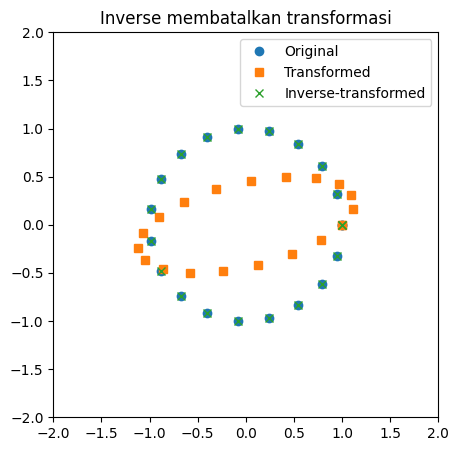

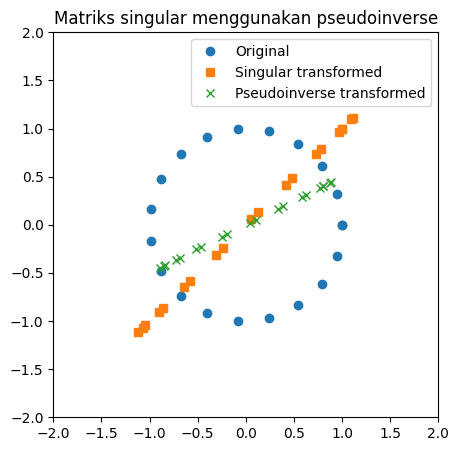

In [17]:
theta = np.linspace(0, 2*np.pi, 20)
P = np.vstack((np.cos(theta), np.sin(theta)))

T = np.array([[1, .5], [0, .5]])
Q = T @ P
U = np.linalg.inv(T) @ Q

plt.figure(figsize=(5, 5))
plt.plot(P[0, :], P[1, :], 'o', label='Original')
plt.plot(Q[0, :], Q[1, :], 's', label='Transformed')
plt.plot(U[0, :], U[1, :], 'x', label='Inverse-transformed')
plt.axis('square')
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.legend()
plt.title('Inverse membatalkan transformasi')
plt.show()

# Matriks noninvertible
T_singular = np.array([[1, .5], [1, .5]])
Q_singular = T_singular @ P
U_pinv = np.linalg.pinv(T_singular) @ Q_singular

plt.figure(figsize=(5, 5))
plt.plot(P[0, :], P[1, :], 'o', label='Original')
plt.plot(Q_singular[0, :], Q_singular[1, :], 's', label='Singular transformed')
plt.plot(U_pinv[0, :], U_pinv[1, :], 'x', label='Pseudoinverse transformed')
plt.axis('square')
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.legend()
plt.title('Matriks singular menggunakan pseudoinverse')
plt.show()

## Exercise 8-9

Membuat Hilbert matrix dengan fungsi sendiri, lalu membandingkannya dengan `scipy.linalg.hilbert`.

Jarak fungsi sendiri dengan scipy.linalg.hilbert:
0.0


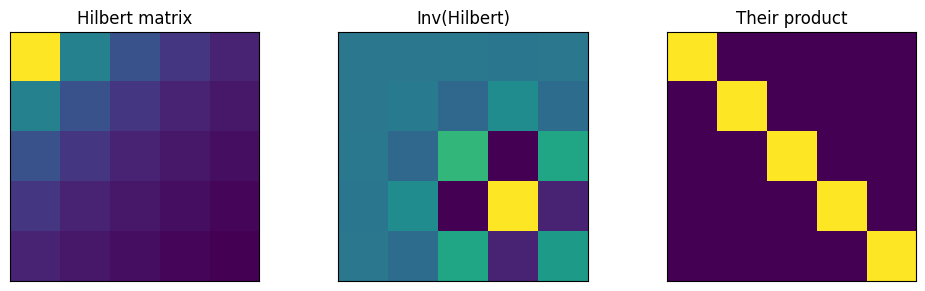

In [18]:
def hilbert_matrix(n):
  H = np.zeros((n, n))
  for i in range(n):
    for j in range(n):
      H[i, j] = 1 / (i + j + 1)
  return H

H = hilbert_matrix(5)
H_scipy = hilbert(5)
Hinv = np.linalg.inv(H)
product = H @ Hinv

print('Jarak fungsi sendiri dengan scipy.linalg.hilbert:')
print(np.linalg.norm(H - H_scipy))

fig, axs = plt.subplots(1, 3, figsize=(10, 3))
plots = [H, Hinv, product]
titles = ['Hilbert matrix', 'Inv(Hilbert)', 'Their product']

for ax, mat, title in zip(axs, plots, titles):
  ax.imshow(mat)
  ax.set_title(title)
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()

## Exercise 8-10

Mengukur Euclidean distance antara hasil $A A^{-1}$ dan identity matrix, serta condition number untuk Hilbert matrix dan random matrix.

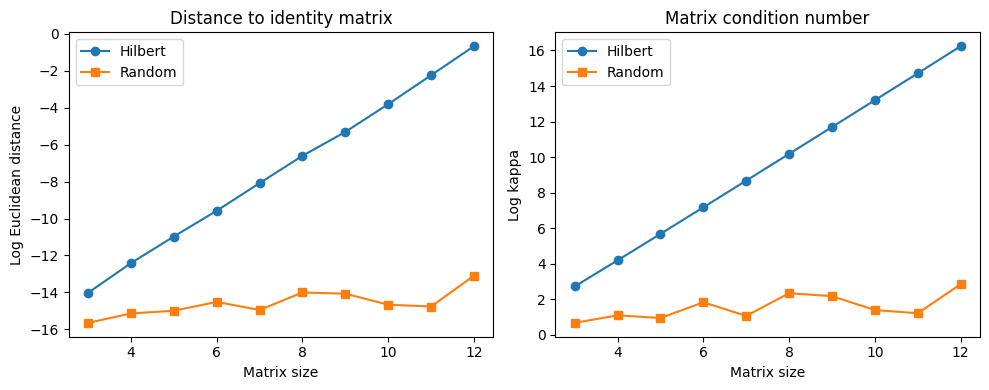

In [19]:
sizes = range(3, 13)

hilbert_distances = []
random_distances = []
hilbert_conds = []
random_conds = []

for n in sizes:
  H = hilbert_matrix(n)
  H_inv = np.linalg.inv(H)
  H_product = H @ H_inv
  I = np.eye(n)

  hilbert_distances.append(np.linalg.norm(H_product - I))
  hilbert_conds.append(np.linalg.cond(H))

  R = np.random.randn(n, n)
  R_inv = np.linalg.inv(R)
  R_product = R @ R_inv

  random_distances.append(np.linalg.norm(R_product - I))
  random_conds.append(np.linalg.cond(R))

hilbert_distances = np.array(hilbert_distances)
random_distances = np.array(random_distances)
hilbert_conds = np.array(hilbert_conds)
random_conds = np.array(random_conds)

eps = np.finfo(float).eps

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(list(sizes), np.log10(np.maximum(hilbert_distances, eps)), 'o-', label='Hilbert')
plt.plot(list(sizes), np.log10(np.maximum(random_distances, eps)), 's-', label='Random')
plt.xlabel('Matrix size')
plt.ylabel('Log Euclidean distance')
plt.title('Distance to identity matrix')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(list(sizes), np.log10(hilbert_conds), 'o-', label='Hilbert')
plt.plot(list(sizes), np.log10(random_conds), 's-', label='Random')
plt.xlabel('Matrix size')
plt.ylabel('Log kappa')
plt.title('Matrix condition number')
plt.legend()

plt.tight_layout()
plt.show()

## Ringkasan

- Matrix inverse digunakan untuk membatalkan transformasi matriks dan menyelesaikan persamaan matriks.
- Square full-rank matrix memiliki full inverse.
- Tall full column-rank matrix memiliki left-inverse.
- Wide full row-rank matrix memiliki right-inverse.
- Reduced-rank matrix tidak memiliki full inverse, tetapi memiliki pseudoinverse.
- Menghitung inverse dapat bermasalah secara numerik, terutama pada matriks seperti Hilbert matrix.